In [1]:
#importing all necessary libraries

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Subset, random_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # using GPU
print("Using device:", device)

Using device: cuda


In [20]:
# transforming the data to be used to train the model 
transform = transforms.Compose([
    transforms.Grayscale(3),       
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [21]:
# downloading the dataset (training and testing separately)
train_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=True, download=True, transform=transform) 
test_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=False, download=True, transform=transform)

# Using dataloader to load data efficiently and use it more optimally by parallely putting it in CPU cores
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [22]:
# Defining the CNN model according to the question given
class CNN_MNIST(nn.Module):
    def __init__(self):
        super(CNN_MNIST, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # defining the convolutional layer of 32 filters of size 3x3
        self.pool = nn.MaxPool2d(2, 2) # defining a layer of maxpool of 2x2 filter
        self.fc1 = nn.Linear(32 * 14 * 14, 128) # taking input from convolution layer and transforming it to 128 layer
        self.fc2 = nn.Linear(128, 10) # defining the penultimate layer 
        self.relu = nn.ReLU() # adding nonlinearity using ReLU

    def forward(self, x):
        x = self.relu(self.conv1(x)) 
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [23]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience=5): # Program to train model
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Training loop
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct_train / total_train * 100

        # Validation loop if validation loss increases for more than 5 epochs then the model has started overfitting so break the training process
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val * 100

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Early stopping logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), './cnn_model.pth')
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            break


In [24]:
cnn_model = CNN_MNIST().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(),lr=0.001)

train_size = 54000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size]) # dividing the dataset into training and validation subsets

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1000, shuffle=False)

In [25]:
train_model(cnn_model,train_loader,val_loader,criterion,optimizer,20) #training the CNN on MNIST

Epoch [1/20] | Train Loss: 0.1842 | Train Acc: 94.45% | Val Loss: 0.0712 | Val Acc: 97.75%
Epoch [2/20] | Train Loss: 0.0604 | Train Acc: 98.11% | Val Loss: 0.0628 | Val Acc: 98.17%
Epoch [3/20] | Train Loss: 0.0391 | Train Acc: 98.78% | Val Loss: 0.0526 | Val Acc: 98.45%
Epoch [4/20] | Train Loss: 0.0288 | Train Acc: 99.05% | Val Loss: 0.0493 | Val Acc: 98.58%
Epoch [5/20] | Train Loss: 0.0214 | Train Acc: 99.28% | Val Loss: 0.0547 | Val Acc: 98.53%
Epoch [6/20] | Train Loss: 0.0161 | Train Acc: 99.48% | Val Loss: 0.0539 | Val Acc: 98.67%
Epoch [7/20] | Train Loss: 0.0120 | Train Acc: 99.63% | Val Loss: 0.0576 | Val Acc: 98.58%
Epoch [8/20] | Train Loss: 0.0123 | Train Acc: 99.57% | Val Loss: 0.0594 | Val Acc: 98.45%
Epoch [9/20] | Train Loss: 0.0087 | Train Acc: 99.69% | Val Loss: 0.0580 | Val Acc: 98.53%

Early stopping triggered at epoch 9


In [26]:
torch.save(cnn_model.state_dict(),'./cnnmodel.pth') # Saving the model 

In [27]:
# Evaluating the model
cnn_model.eval()
y_pred = []
y_label = []
t_start = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        output = cnn_model(img)

        # getting predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end = time.time()

y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)

print(f"Shape of y_pred = {y_pred.shape}")
print(f"Shape of y_label = {y_label.shape}")


Shape of y_pred = (10000,)
Shape of y_label = (10000,)


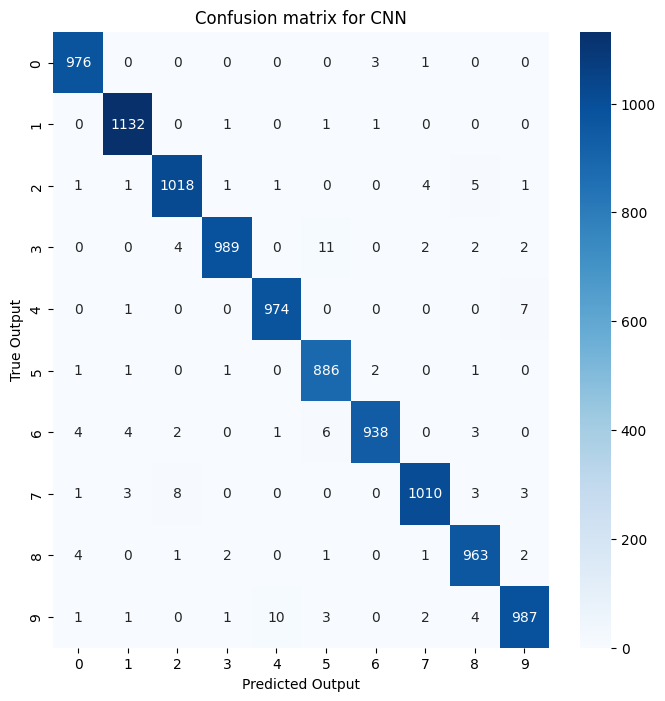

Accuracy for CNN = 98.73
F1 score for CNN = 0.9871921839543587
The Inference time needed for CNN model is 3.1551742553710938s
Total number of parameters: 805130


In [28]:
accuracy_cnn = ((y_pred == y_label).sum())/100 # finding accuracy on test data
f1_cnn = f1_score(y_label,y_pred,average = "macro") # finding f1 score on test data
cm_cnn = confusion_matrix(y_label,y_pred) 

plt.figure(figsize=(8,8))
sns.heatmap(cm_cnn,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for CNN")
plt.show()
print(f"Accuracy for CNN = {accuracy_cnn}")
print(f"F1 score for CNN = {f1_cnn}")
print(f"The Inference time needed for CNN model is {t_end - t_start}s")

total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Total number of parameters: {total_params}') # printing the number of parameters in the CNN

### Using Pretrained CNNs like Mobilenet and Efficientnet to compare performance with defined CNN

In [4]:
# Data needs to be transformed to meet requirements of pretrained model
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [5]:
train_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./dataset_q3', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, shuffle=False)


In [6]:
mobilenet_model = models.mobilenet_v2(pretrained = True) # loading the pretrained mobilenet model

mobilenet_params = sum(p.numel() for p in mobilenet_model.parameters() if p.requires_grad) # finding the number of parameters in the model

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /home/zeus/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


  0%|          | 0.00/13.6M [00:00<?, ?B/s]

100%|██████████| 13.6M/13.6M [00:00<00:00, 81.7MB/s]


In [9]:
for p in mobilenet_model.features.parameters(): # Freezing all the layers except the last as we dont want to train the entire model but just adapt according to our output layer
    p.requires_grad = False

mobilenet_model.classifier[1] = nn.Linear(mobilenet_model.last_channel,10) # modifying output layer as we have 10 classes

mobilenet_model = mobilenet_model.to(device)

criterion = nn.CrossEntropyLoss() # Using crossentropy loss 

optimizer_mobilenet = torch.optim.Adam(mobilenet_model.parameters(),lr = 1e-3)

train_size = 54000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1000, shuffle=False)

In [10]:
train_model(mobilenet_model, train_loader, val_loader, criterion, optimizer_mobilenet, epochs=10) # training the model


Epoch [1/10] | Train Loss: 0.3932 | Train Acc: 89.32% | Val Loss: 0.1892 | Val Acc: 94.50%
Epoch [2/10] | Train Loss: 0.2072 | Train Acc: 93.66% | Val Loss: 0.1614 | Val Acc: 95.32%
Epoch [3/10] | Train Loss: 0.1844 | Train Acc: 94.14% | Val Loss: 0.1374 | Val Acc: 95.68%
Epoch [4/10] | Train Loss: 0.1712 | Train Acc: 94.46% | Val Loss: 0.1153 | Val Acc: 96.43%
Epoch [5/10] | Train Loss: 0.1623 | Train Acc: 94.67% | Val Loss: 0.1124 | Val Acc: 96.80%
Epoch [6/10] | Train Loss: 0.1598 | Train Acc: 94.82% | Val Loss: 0.1054 | Val Acc: 96.70%
Epoch [7/10] | Train Loss: 0.1599 | Train Acc: 94.81% | Val Loss: 0.1060 | Val Acc: 96.82%
Epoch [8/10] | Train Loss: 0.1550 | Train Acc: 94.98% | Val Loss: 0.1109 | Val Acc: 96.42%
Epoch [9/10] | Train Loss: 0.1529 | Train Acc: 94.93% | Val Loss: 0.1195 | Val Acc: 96.32%
Epoch [10/10] | Train Loss: 0.1519 | Train Acc: 95.07% | Val Loss: 0.1048 | Val Acc: 96.85%


In [11]:
# evaluating the model
mobilenet_model.eval()
y_pred = []
y_label = []
t_start_mb = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        output = mobilenet_model(img)

        # getting predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end_mb = time.time()

y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)



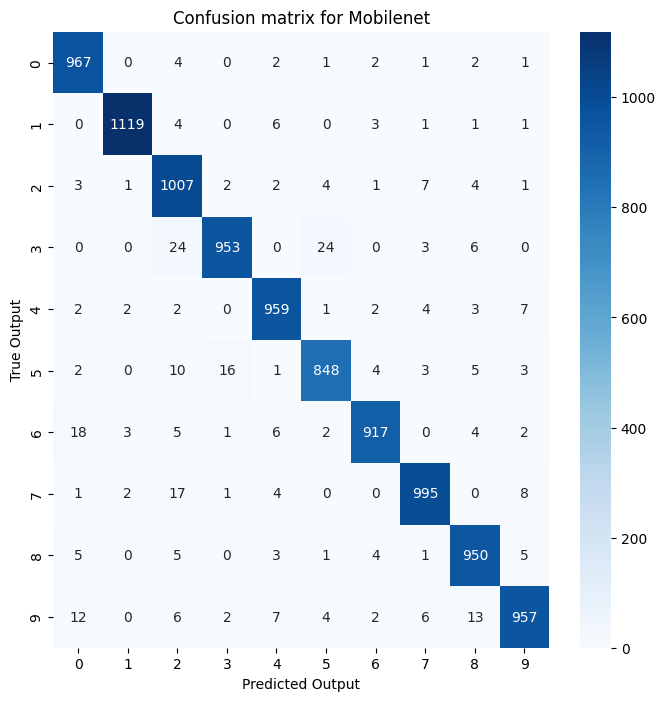

Accuracy for Mobilenet = 96.72
F1 score for Mobilenet = 0.9668597998184059
The Inference time needed for Mobilenet model is 81.88482284545898s
Total number of parameters: 3504872


In [12]:
accuracy_mb = ((y_pred == y_label).sum())/100
f1_mb = f1_score(y_label,y_pred,average = "macro")
cm_mb = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_mb,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for Mobilenet")
plt.show()
print(f"Accuracy for Mobilenet = {accuracy_mb}")
print(f"F1 score for Mobilenet = {f1_mb}")
print(f"The Inference time needed for Mobilenet model is {t_end_mb - t_start_mb}s")


print(f'Total number of parameters: {mobilenet_params}')

In [7]:
efficientnet_model = models.efficientnet_b0(pretrained = True)

efficientnet_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [9]:
for p in efficientnet_model.features.parameters(): # Freezing all the layers except the last as we dont want to train the entire model but just adapt according to our output layer
    p.requires_grad = False

efficientnet_model.classifier[1] = nn.Linear(efficientnet_model.classifier[1].in_features, 10) # modifying output layer as we have 10 classes

efficientnet_model = efficientnet_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_efficientnet = torch.optim.Adam(efficientnet_model.parameters(),lr = 1e-3)




In [11]:
train_size = 54000
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=1000, shuffle=False)

In [14]:
train_model(efficientnet_model, train_loader, val_loader, criterion, optimizer_efficientnet, epochs=10) # training the model


Epoch [1/10] | Train Loss: 0.4904 | Train Acc: 87.54% | Val Loss: 0.1864 | Val Acc: 94.80%
Epoch [2/10] | Train Loss: 0.2690 | Train Acc: 91.98% | Val Loss: 0.1392 | Val Acc: 95.82%
Epoch [3/10] | Train Loss: 0.2371 | Train Acc: 92.81% | Val Loss: 0.1263 | Val Acc: 96.32%
Epoch [4/10] | Train Loss: 0.2268 | Train Acc: 92.89% | Val Loss: 0.1197 | Val Acc: 96.45%
Epoch [5/10] | Train Loss: 0.2158 | Train Acc: 93.15% | Val Loss: 0.1086 | Val Acc: 96.73%
Epoch [6/10] | Train Loss: 0.2099 | Train Acc: 93.44% | Val Loss: 0.1048 | Val Acc: 96.77%
Epoch [7/10] | Train Loss: 0.2060 | Train Acc: 93.48% | Val Loss: 0.1022 | Val Acc: 96.90%
Epoch [8/10] | Train Loss: 0.2021 | Train Acc: 93.51% | Val Loss: 0.0990 | Val Acc: 96.95%
Epoch [9/10] | Train Loss: 0.1976 | Train Acc: 93.55% | Val Loss: 0.1012 | Val Acc: 96.90%
Epoch [10/10] | Train Loss: 0.1971 | Train Acc: 93.67% | Val Loss: 0.0967 | Val Acc: 97.08%


In [15]:
# evaluating the model
efficientnet_model.eval()
y_pred = []
y_label = []
t_start_eff = time.time()
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        label = label.to(device)

        # no flattening here!
        output = efficientnet_model(img)

        # get predicted class
        prediction = torch.argmax(output, dim=1)

        y_pred.append(prediction.cpu().numpy())
        y_label.append(label.cpu().numpy())

t_end_eff = time.time()
# combine all batches
y_pred = np.concatenate(y_pred)
y_label = np.concatenate(y_label)


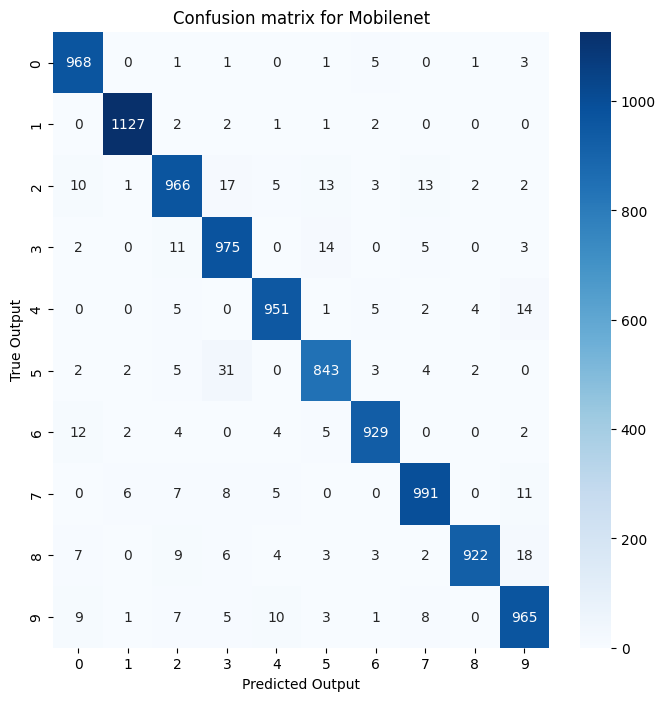

Accuracy for Efficientnet = 96.37
F1 score for Efficientnet = 0.9633442553084057
The Inference time needed for Mobilenet model is 105.96545767784119s
Total number of parameters: 5288548


In [16]:
accuracy_eff = ((y_pred == y_label).sum())/100
f1_eff = f1_score(y_label,y_pred,average = "macro")
cm_eff = confusion_matrix(y_label,y_pred)

plt.figure(figsize=(8,8))
sns.heatmap(cm_eff,annot=True,fmt="d",cmap="Blues", xticklabels= np.unique(y_label),
        yticklabels= np.unique(y_label))
plt.xlabel("Predicted Output")
plt.ylabel("True Output")
plt.title("Confusion matrix for Mobilenet")
plt.show()
print(f"Accuracy for Efficientnet = {accuracy_eff}")
print(f"F1 score for Efficientnet = {f1_eff}")
print(f"The Inference time needed for Mobilenet model is {t_end_eff - t_start_eff}s")


print(f'Total number of parameters: {efficientnet_params}')

In [19]:
torch.save(efficientnet_model.state_dict(),'./efficientnetodel.pth') # saving the model

## Comparing all the 3 models in terms of  Compare all three models:
	- Accuracy, F1-score, confusion matrix
	- Model size (number of parameters)
	- Inference time on test set

Defined CNN
- Accuracy: = 98.73%
- F1 Score:  0.9871921839543587
- Inference Time: 3.1551742553710938s
- Total Parameters: 805130

Mobilenet
- Accuracy: = 96.72%
- F1 Score:  0.9668597998184059
- Inference Time: 81.88482284545898s
- Total Parameters: 3504872


Efficientnet
- Accuracy: = 96.37%
- F1 Score:  0.9633442553084057
- Inference Time: 105.96545767784119s
- Total Parameters: 5288548

- In terms of efficiency Defined CNN performs better than Mobilenet and Efficientnet as it has greater test accuracy and F1 score   as    the pretrained models are used for complex colored images, whereas the CNN (custom) is defined for these images only

- The Defined CNN has less inference time also as it has less number of parameters, making the evaluation faster but Mobilenet and Efficientnet are verry big models with deep layers making the evaluation process very slow